<a href="https://colab.research.google.com/github/iamkhan49/heart-disease-prediction-ml/blob/main/Heart_Disease_Detection_using_Classification_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ❤️ Heart Disease Detection using Classification Algorithms

## Machine Learning Classification Project

### Dataset
Heart Disease Dataset

### Objective
Build a Machine Learning model that predicts whether a patient has heart disease based on medical attributes.

### Algorithm
Logistic Regression

### Developed By


*   Anas Ahmad Khan
*   Khwaja Danish oddin


*   Abdul Imran
*   Syed Faisal




*   Hamza Ansari
*   Danish Khan




# Project Objective

The objective of this project is to develop a Machine Learning classification model that predicts the presence of heart disease using patient medical information.

This project includes:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Feature Selection
- Model Training
- Model Evaluation
- Hyperparameter Tuning
- Prediction on New Data
- Model Saving

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

%matplotlib inline

# Upload Dataset

Upload the **heart_disease_dataset.csv** file from your computer.

In [2]:
uploaded = files.upload()

Saving heart_disease_dataset.csv to heart_disease_dataset.csv


In [3]:
df = pd.read_csv("heart_disease_dataset.csv")

# Display First Five Records

In [4]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1


# Dataset Shape

In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (400, 14)


# Column Names

In [6]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_induced_angina', 'st_depression', 'st_slope',
       'num_major_vessels', 'thalassemia', 'heart_disease'],
      dtype='object')

# Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    int64  
 1   sex                      400 non-null    int64  
 2   chest_pain_type          400 non-null    int64  
 3   resting_blood_pressure   400 non-null    int64  
 4   cholesterol              400 non-null    int64  
 5   fasting_blood_sugar      400 non-null    int64  
 6   resting_ecg              400 non-null    int64  
 7   max_heart_rate           400 non-null    int64  
 8   exercise_induced_angina  400 non-null    int64  
 9   st_depression            400 non-null    float64
 10  st_slope                 400 non-null    int64  
 11  num_major_vessels        400 non-null    int64  
 12  thalassemia              400 non-null    int64  
 13  heart_disease            400 non-null    int64  
dtypes: float64(1), int64(13)
m

# Statistical Summary

In [8]:
df.describe()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,53.667500,0.662500,1.712500,123.630000,216.627500,0.140000,0.530000,146.717500,0.29250,0.753250,1.177500,0.677500,1.925000,0.555000
std,8.508403,0.473449,1.035628,16.567114,41.379941,0.347422,0.533678,21.104293,0.45548,0.772841,0.645784,0.889084,0.689611,0.497588
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,91.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,1.000000,112.000000,188.000000,0.000000,0.000000,132.000000,0.00000,0.200000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,2.000000,124.000000,216.000000,0.000000,1.000000,146.000000,0.00000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,59.000000,1.000000,3.000000,135.000000,246.000000,0.000000,1.000000,161.000000,1.00000,0.900000,2.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,174.000000,336.000000,1.000000,2.000000,202.000000,1.00000,4.900000,2.000000,3.000000,3.000000,1.000000


In [9]:
df.describe(include="all")

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,53.667500,0.662500,1.712500,123.630000,216.627500,0.140000,0.530000,146.717500,0.29250,0.753250,1.177500,0.677500,1.925000,0.555000
std,8.508403,0.473449,1.035628,16.567114,41.379941,0.347422,0.533678,21.104293,0.45548,0.772841,0.645784,0.889084,0.689611,0.497588
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,91.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,1.000000,112.000000,188.000000,0.000000,0.000000,132.000000,0.00000,0.200000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,2.000000,124.000000,216.000000,0.000000,1.000000,146.000000,0.00000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,59.000000,1.000000,3.000000,135.000000,246.000000,0.000000,1.000000,161.000000,1.00000,0.900000,2.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,174.000000,336.000000,1.000000,2.000000,202.000000,1.00000,4.900000,2.000000,3.000000,3.000000,1.000000


In [10]:
print("\nDataset Preview")
display(df.head())

print("\nRandom Sample")
display(df.sample(5))


Dataset Preview


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1



Random Sample


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
245,50,1,3,98,214,0,1,122,0,2.5,2,1,2,1
48,57,1,0,118,175,0,1,144,0,0.9,1,0,2,1
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
53,59,0,2,107,211,0,0,200,0,0.2,1,2,2,0
138,61,0,2,143,272,0,1,126,0,0.7,1,0,2,0


# Missing Values

In [11]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholesterol,0
fasting_blood_sugar,0
resting_ecg,0
max_heart_rate,0
exercise_induced_angina,0
st_depression,0


In [12]:
# Total Missing Values

print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


# Handle Missing Values

In [13]:
# Remove missing values if any

df = df.dropna()

print("Dataset Shape After Removing Missing Values:", df.shape)

Dataset Shape After Removing Missing Values: (400, 14)


In [14]:
# Verify missing values

df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholesterol,0
fasting_blood_sugar,0
resting_ecg,0
max_heart_rate,0
exercise_induced_angina,0
st_depression,0


# Duplicate Records

In [15]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Remove Duplicate Records

In [16]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (400, 14)


In [17]:
print("Duplicate Rows Remaining:", df.duplicated().sum())

Duplicate Rows Remaining: 0


# Data Types

In [18]:
df.dtypes

,0
age,int64
sex,int64
chest_pain_type,int64
resting_blood_pressure,int64
cholesterol,int64
fasting_blood_sugar,int64
resting_ecg,int64
max_heart_rate,int64
exercise_induced_angina,int64
st_depression,float64


In [19]:
# Display all columns with their data types

pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

,Column,Data Type
0,age,int64
1,sex,int64
2,chest_pain_type,int64
3,resting_blood_pressure,int64
4,cholesterol,int64
5,fasting_blood_sugar,int64
6,resting_ecg,int64
7,max_heart_rate,int64
8,exercise_induced_angina,int64
9,st_depression,float64


# Check Unique Values

In [20]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


age
[58 52 59 67 51 68 60 49 56 36 38 48 44 45 41 54 43 57 70 53 61 55 42 40
 47 63 50 62 46 66 30 76 64 73 65 39 71 77 74 37 35 69 29 72 34]

sex
[1 0]

chest_pain_type
[1 2 0 3]

resting_blood_pressure
[134 112 126 165 146 127 129 128 111 115  94 130 118 103 142  96 102 119
 158 113 139 116 136 124 101 140 141 109 120 104 123 121 138 106 100  99
 147 107 145 122 114 110 137 133 135 164 117 108 155 132 160  95  97 105
 148 154 143 166 149 144 162 131 174 152 156 125  98 150 151 159 163 168]

cholesterol
[246 245 196 201 174 137 318 182 204 213 226 231 256 159 193 223 286 228
 233 263 227 152 229 185 262 217 209 292 311 250 126 236 198 247 221 172
 179 234 280 175 218 255 190 206 211 199 205 232 186 187 261 222 271 146
 160 162 322 181 237 293 287 249 202 188 195 257 283 141 183 282 178 290
 253 238 156 266 314 173 203 132 240 158 224 170 279 300 169 191 272 241
 216 167 194 177 259 197 251 235 210 168 214 151 127 244 302 265 166 192
 165 336 207 252 212 264 275 281 219 243 330 273 15

# Check Target Variable Distribution

In [21]:
df["heart_disease"].value_counts()

,count
heart_disease,
1,222
0,178


In [22]:
df["heart_disease"].value_counts(normalize=True) * 100

,proportion
heart_disease,
1,55.5
0,44.5


# Final Dataset Check Before EDA

In [23]:
display(df.head())

print("Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1


Dataset Shape: (400, 14)

Missing Values
age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
resting_ecg                0
max_heart_rate             0
exercise_induced_angina    0
st_depression              0
st_slope                   0
num_major_vessels          0
thalassemia                0
heart_disease              0
dtype: int64

Duplicate Rows: 0


# Exploratory Data Analysis (EDA)

In [24]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1


# Distribution of Target Variable

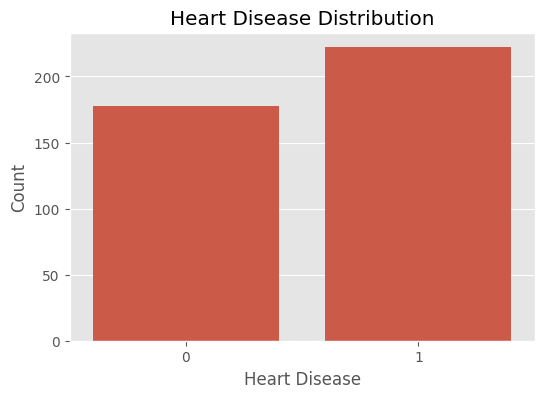

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="heart_disease", data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

# Histograms of Numerical Features

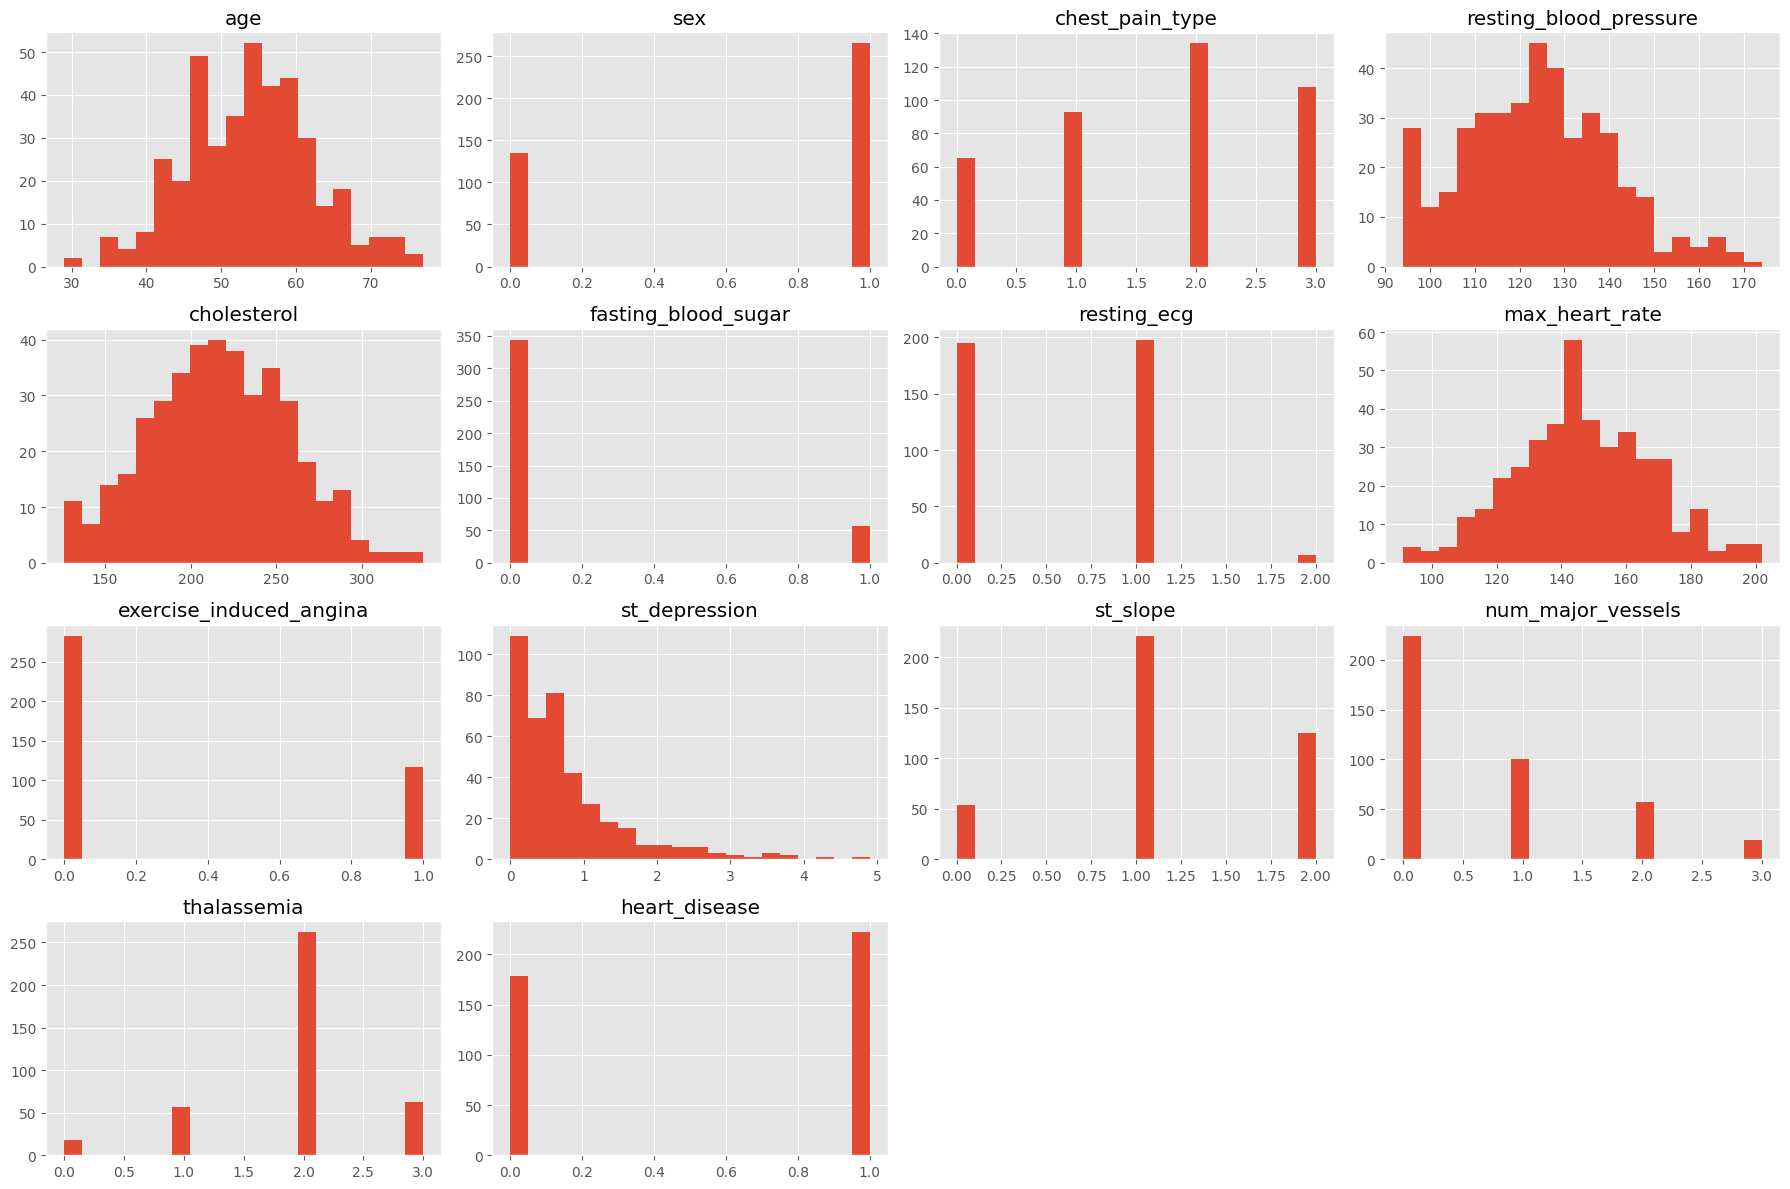

In [26]:
df.hist(figsize=(18,12), bins=20)
plt.tight_layout()
plt.show()

# Boxplots for Outlier Detection

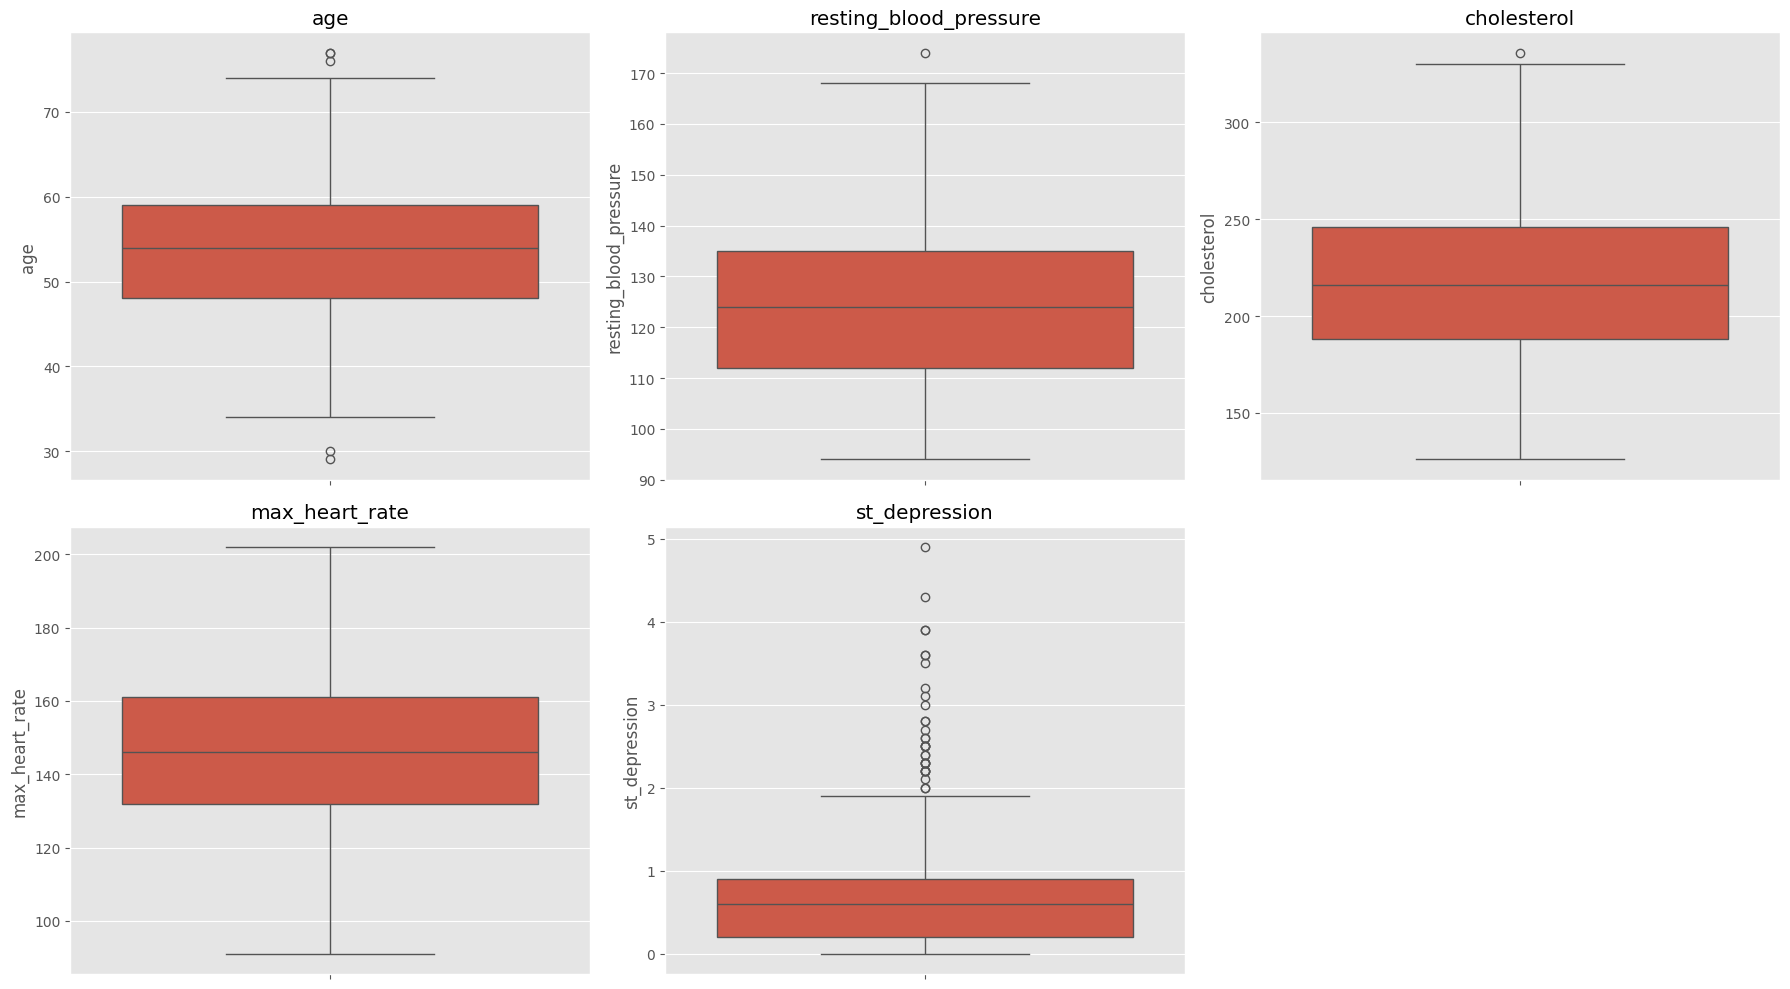

In [27]:
numerical_columns = [
    "age",
    "resting_blood_pressure",
    "cholesterol",
    "max_heart_rate",
    "st_depression"
]

plt.figure(figsize=(18,10))

for i, col in enumerate(numerical_columns,1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Correlation Heatmap

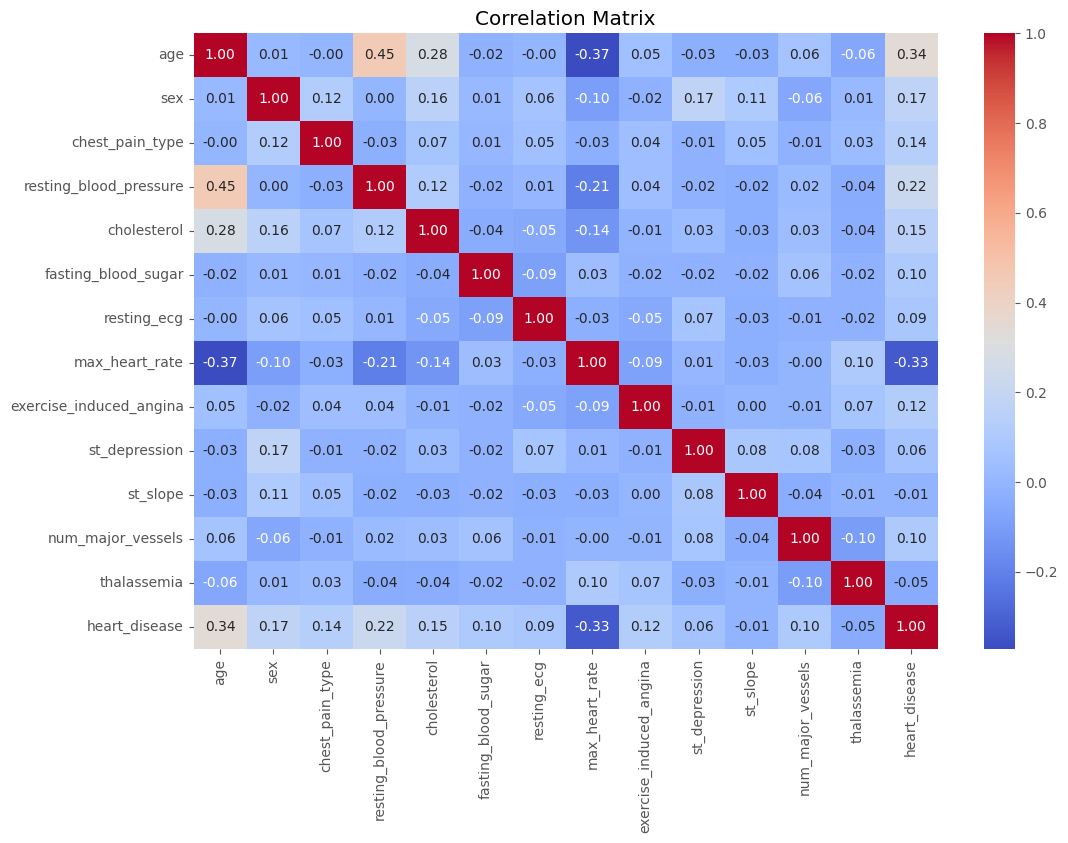

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# Pairplot

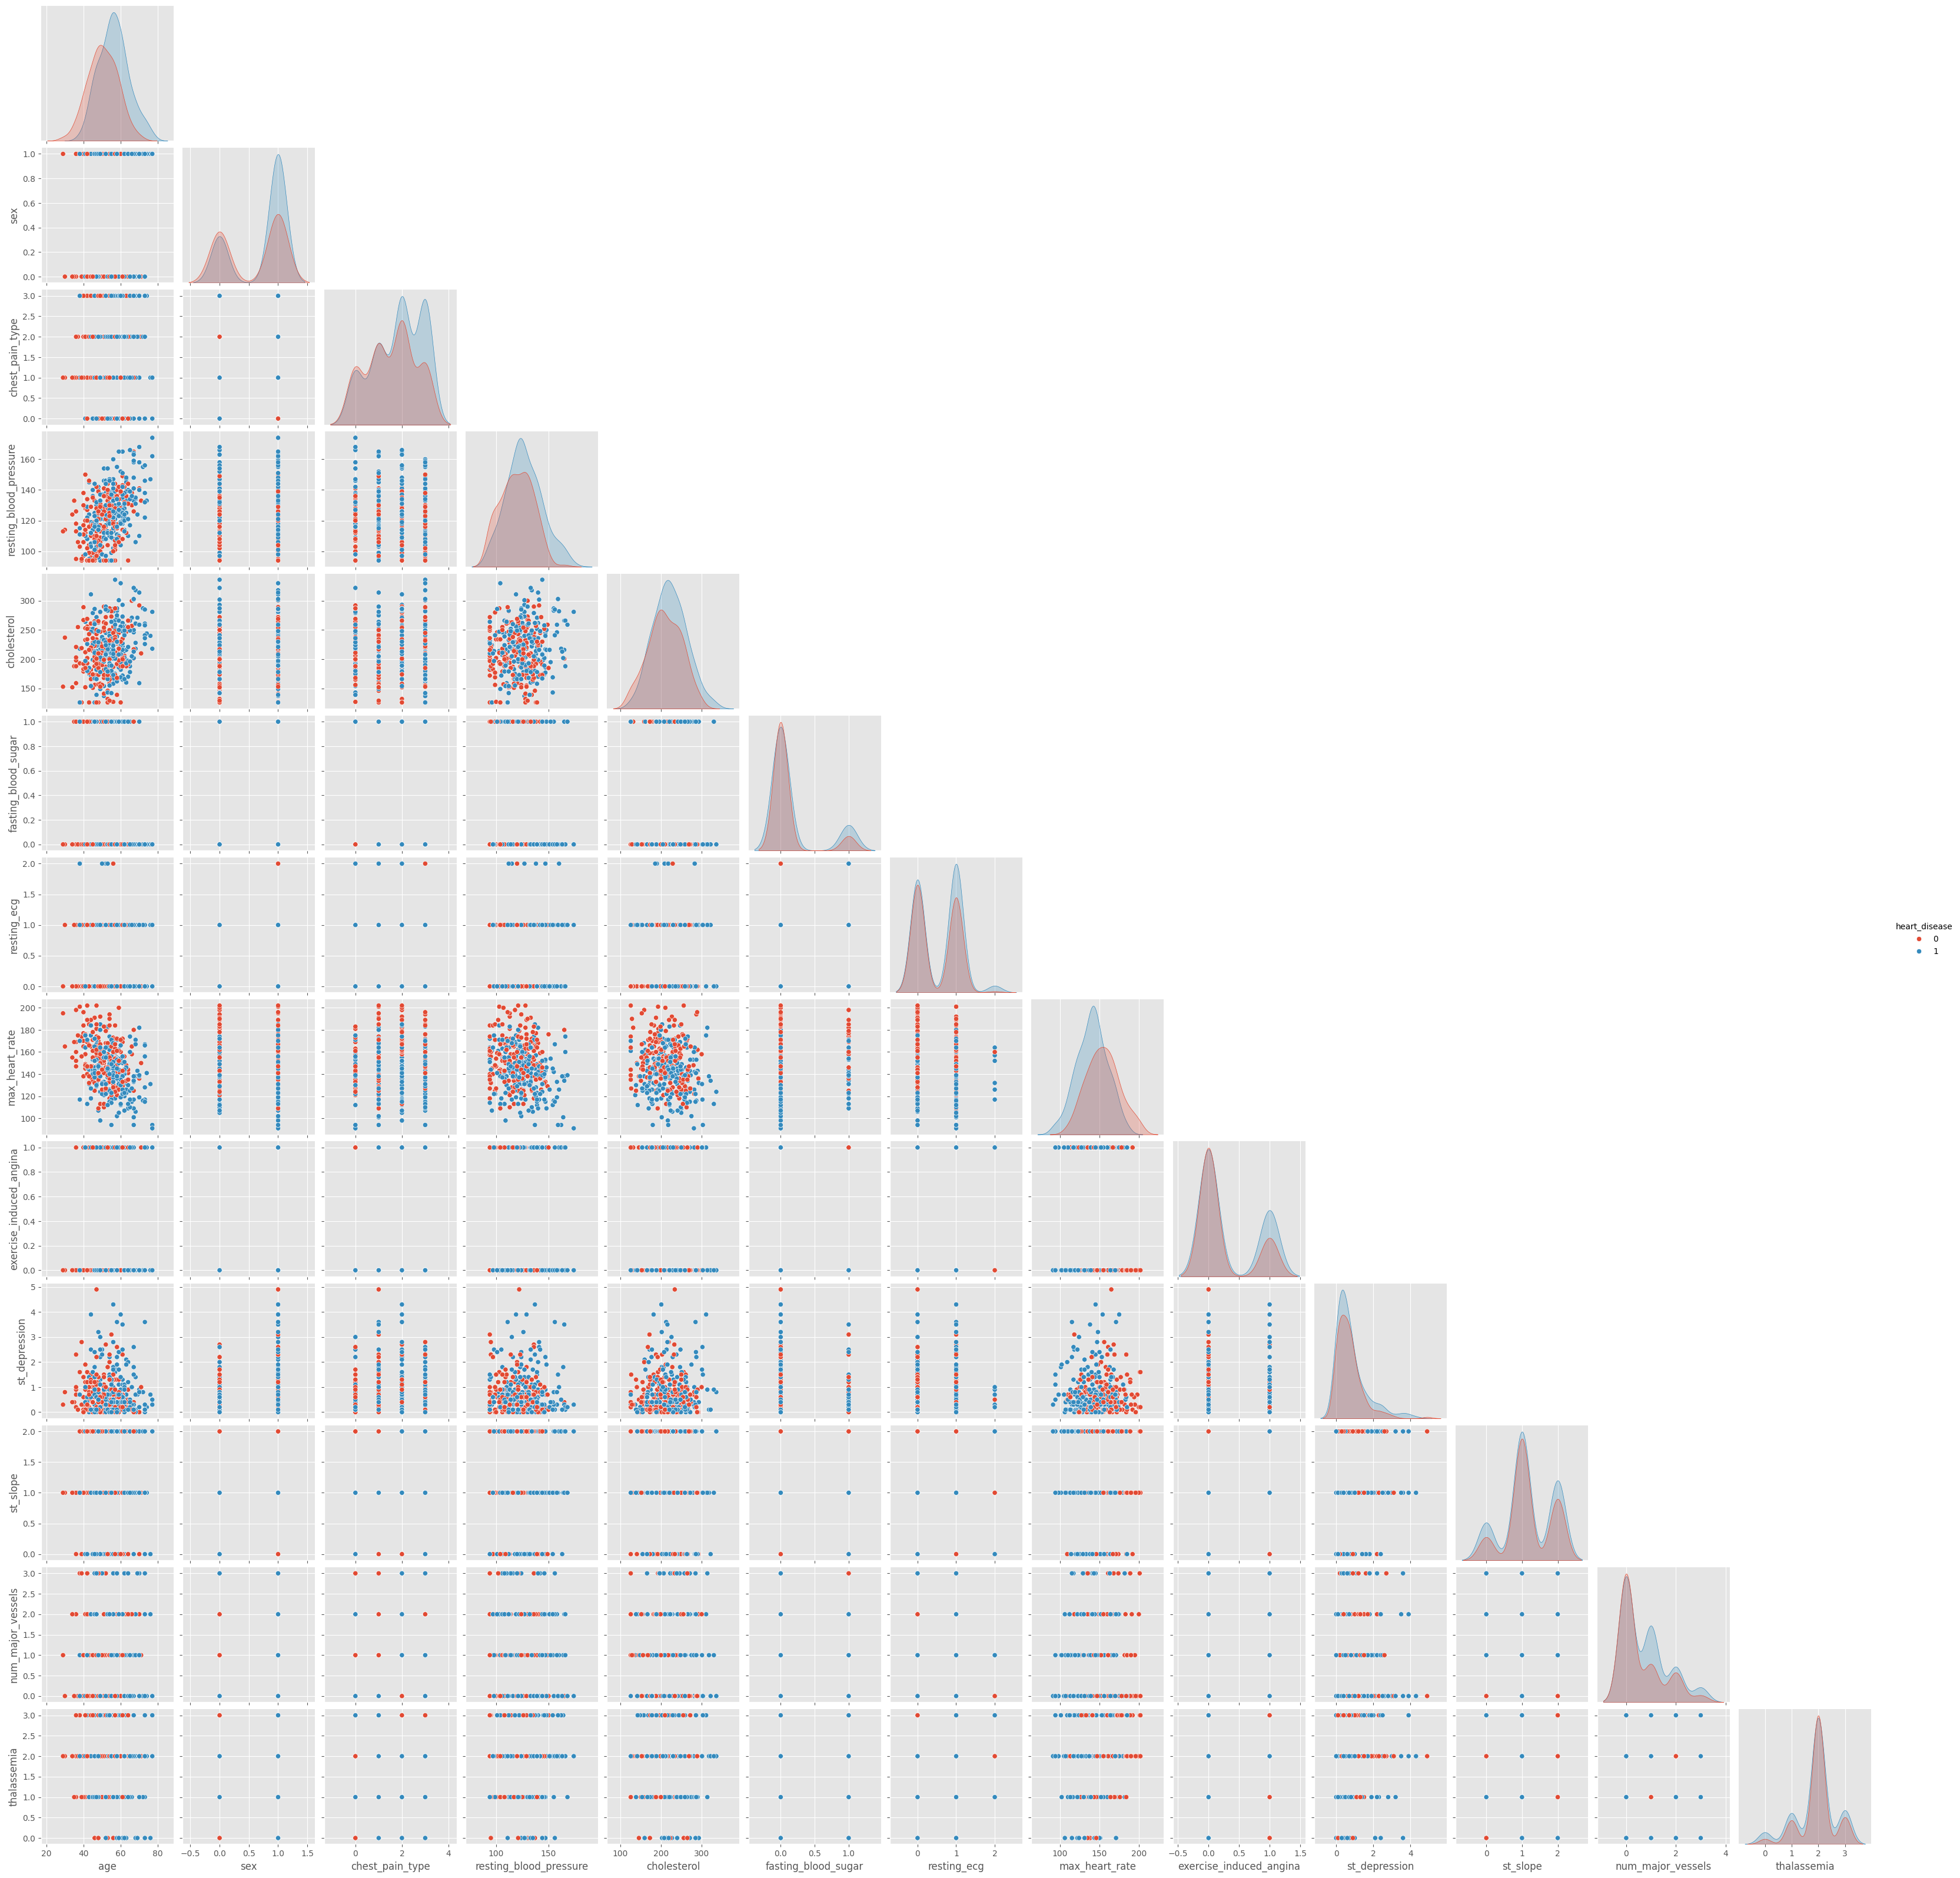

In [29]:
sns.pairplot(
    df,
    hue="heart_disease",
    corner=True
)

plt.show()

# Countplots of Categorical Features

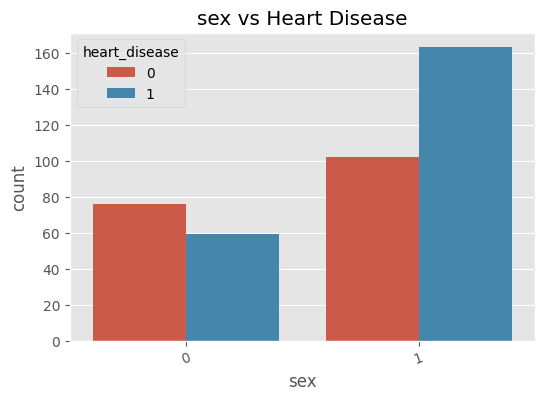

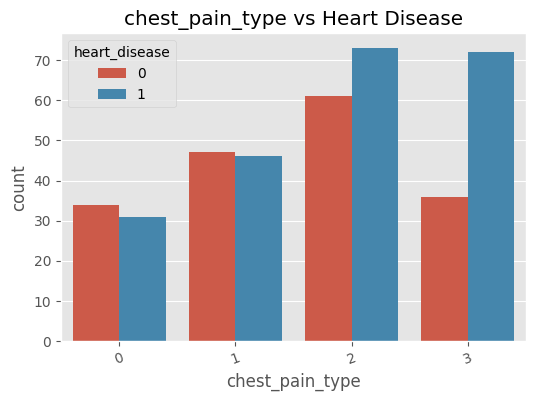

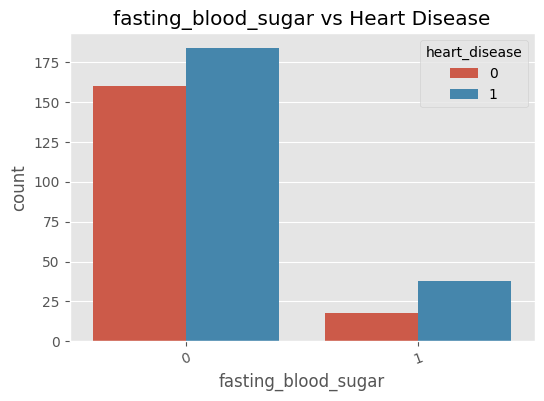

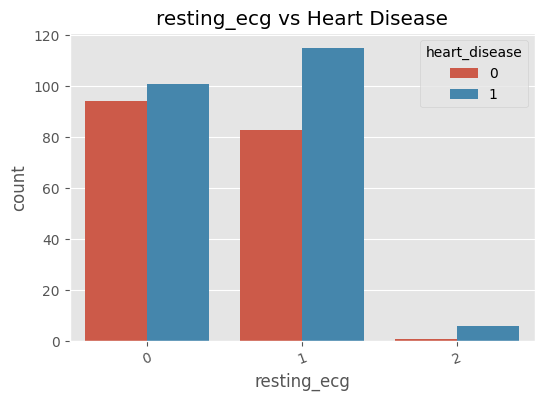

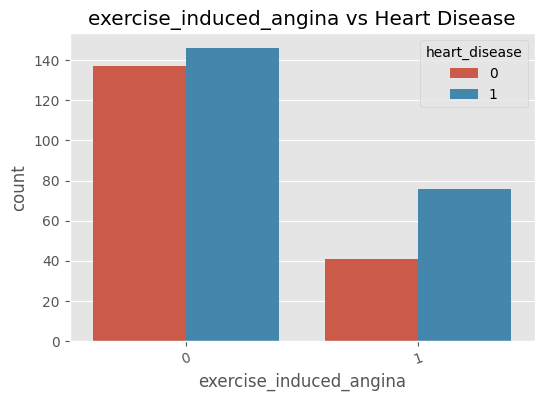

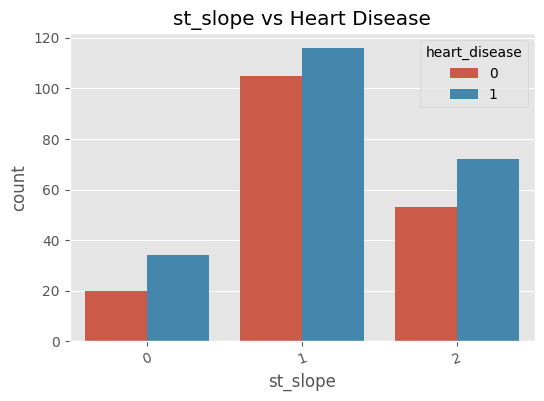

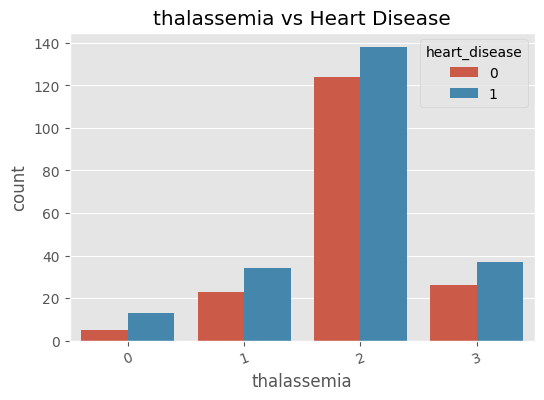

In [30]:
categorical_columns = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_induced_angina",
    "st_slope",
    "thalassemia"
]

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="heart_disease", data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.xticks(rotation=20)
    plt.show()

# Distribution of Numerical Features

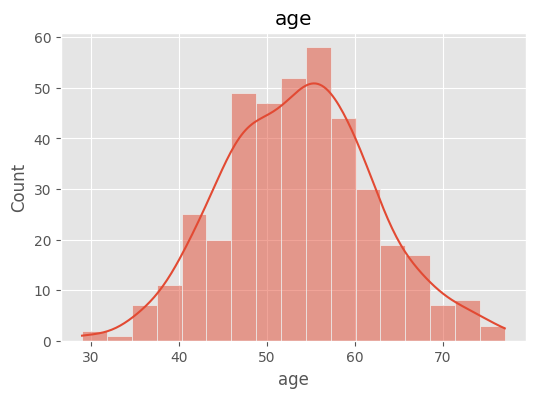

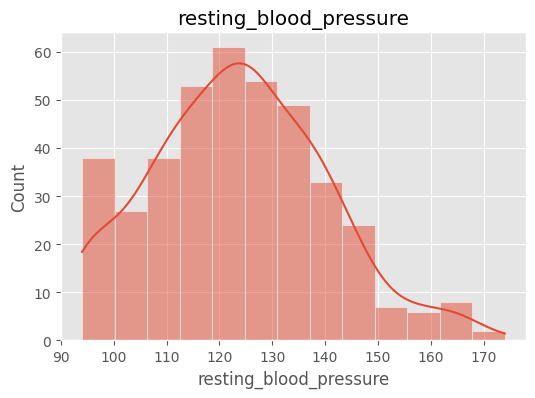

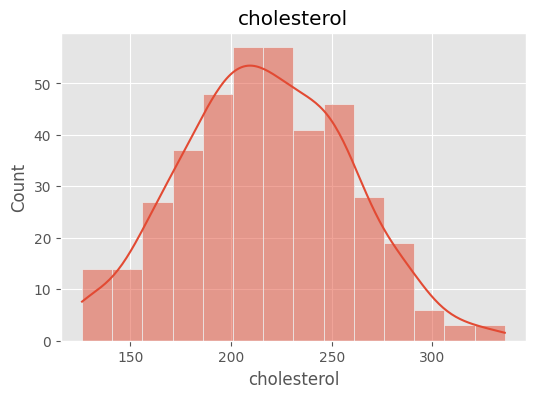

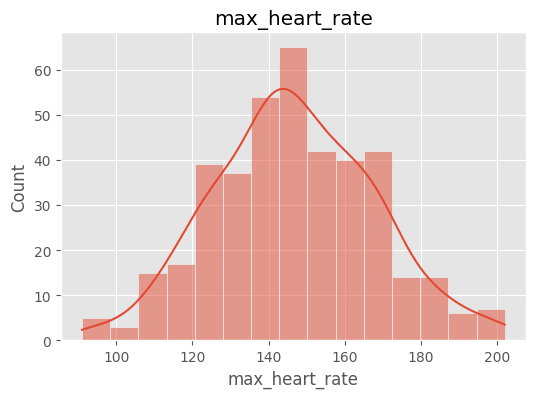

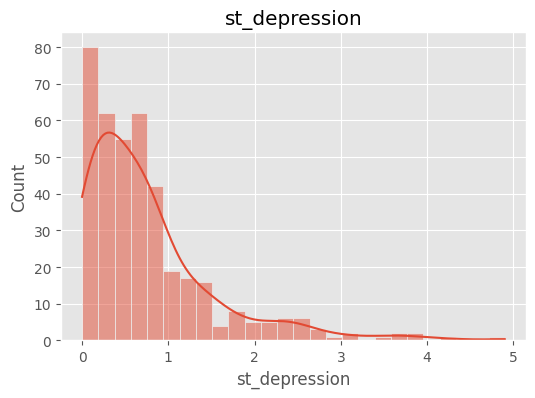

In [31]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# Relationship Between Features and Target

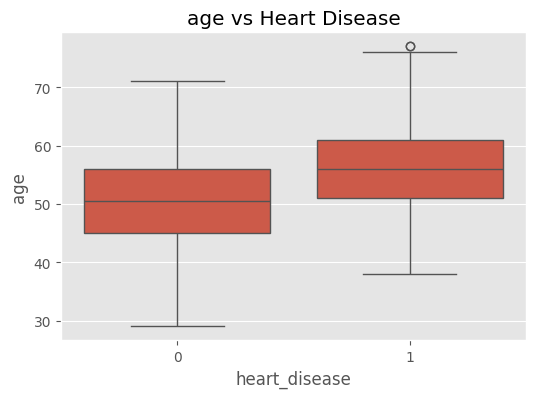

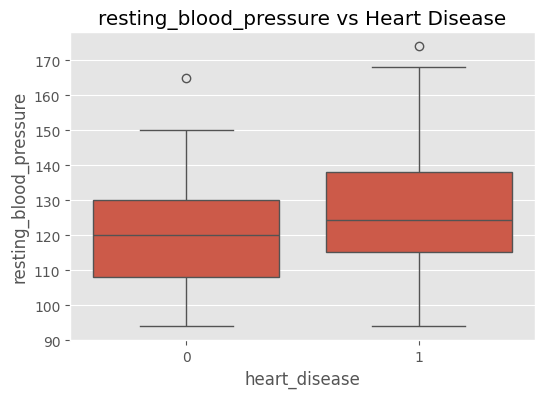

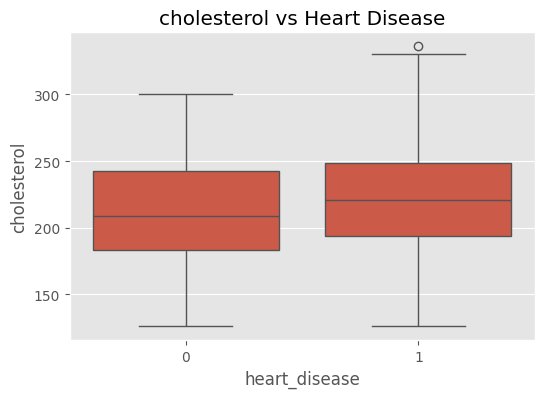

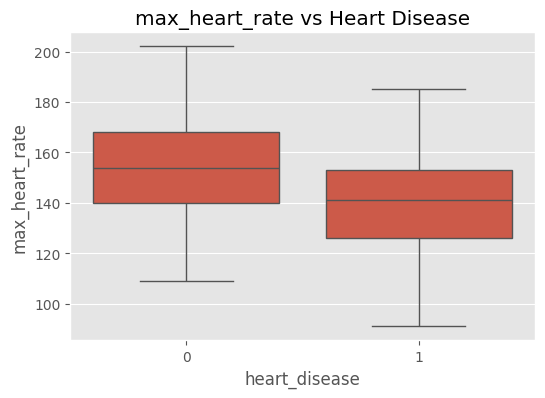

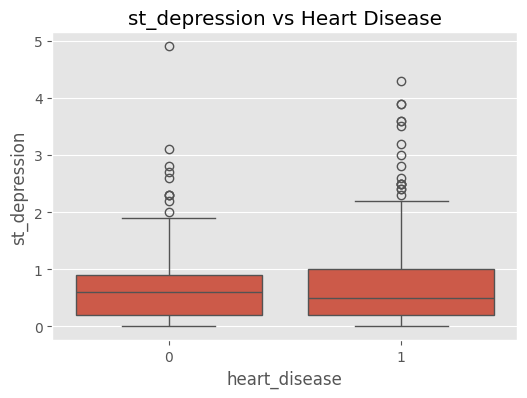

In [32]:
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        x="heart_disease",
        y=col,
        data=df
    )
    plt.title(f"{col} vs Heart Disease")
    plt.show()

# EDA Summary

In [33]:
print("Dataset Shape :", df.shape)
print("Number of Features :", df.shape[1]-1)
print("Target Classes :")
print(df["heart_disease"].value_counts())

Dataset Shape : (400, 14)
Number of Features : 13
Target Classes :
heart_disease
1    222
0    178
Name: count, dtype: int64


# Feature Engineering

In [34]:
# Display first five rows

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1


# Check Data Types

In [35]:
df.dtypes

,0
age,int64
sex,int64
chest_pain_type,int64
resting_blood_pressure,int64
cholesterol,int64
fasting_blood_sugar,int64
resting_ecg,int64
max_heart_rate,int64
exercise_induced_angina,int64
st_depression,float64


# Check Categorical Columns

In [36]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index([], dtype='object')


# Encode Categorical Variables

In [37]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1


# Feature Selection

In [38]:
X = df.drop("heart_disease", axis=1)

y = df["heart_disease"]

# Verify Features and Target

In [39]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (400, 13)
Target Shape : (400,)


In [40]:
X.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2


In [41]:
y.head()

,heart_disease
0,1
1,1
2,1
3,0
4,1


# Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [43]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (320, 13)
Testing Features : (80, 13)
Training Labels : (320,)
Testing Labels : (80,)


# Feature Scaling

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [45]:
print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape :", X_test_scaled.shape)

Scaled Training Shape : (320, 13)
Scaled Testing Shape : (80, 13)


# Data Ready for Model Training

In [46]:
print("Feature Engineering Completed Successfully!")

Feature Engineering Completed Successfully!


# Logistic Regression Model Training

In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

# Model Prediction

In [48]:
y_pred = model.predict(X_test_scaled)

# Training and Testing Accuracy

In [49]:
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")

Training Accuracy : 0.7219
Testing Accuracy  : 0.6750


# Accuracy Score

In [50]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy Score : {accuracy:.4f}")

Accuracy Score : 0.6750


# Model Coefficients

In [51]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,age,0.436748
1,sex,0.379490
2,chest_pain_type,0.262315
3,resting_blood_pressure,0.256487
4,cholesterol,0.153690
5,fasting_blood_sugar,0.321294
6,resting_ecg,0.195984
7,max_heart_rate,-0.554422
8,exercise_induced_angina,0.249065
9,st_depression,0.158638


# Model Intercept

In [52]:
print("Intercept:", model.intercept_[0])

Intercept: 0.31196750690943287


# Prediction Probabilities

In [53]:
y_prob = model.predict_proba(X_test_scaled)

pd.DataFrame(
    y_prob,
    columns=["Probability_No_Disease", "Probability_Heart_Disease"]
).head()

,Probability_No_Disease,Probability_Heart_Disease
0,0.441161,0.558839
1,0.691163,0.308837
2,0.683737,0.316263
3,0.175167,0.824833
4,0.302941,0.697059


# Actual vs Predicted Values

In [54]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(15)

,Actual,Predicted
0,0,1
1,1,0
2,1,0
3,1,1
4,1,1
5,1,1
6,0,0
7,0,1
8,1,1
9,1,1


# Sample Predictions

In [55]:
for i in range(10):
    print(
        f"Actual: {y_test.iloc[i]} | Predicted: {y_pred[i]}"
    )

Actual: 0 | Predicted: 1
Actual: 1 | Predicted: 0
Actual: 1 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 1
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1


# Model Training Completed Successfully

In [56]:
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!
